# Save correct inputs for BayesSpace in R

In [ ]:
import matplotlib.pyplot as plt
import muon
import numpy as np
import requests
import scanpy as sc
import scipy
import scvi
import seaborn as sns
import torch
import re
import louvain
from sklearn.cluster import KMeans
import leidenalg
import igraph
import pandas as pd
import scipy.sparse as sp
from sklearn.metrics import silhouette_score


In [ ]:
mdata = muon.read_h5mu("/Users/mayjang/Desktop/536_project/data/tonsil_pp_svg_clean.h5mu")
rna_adata = mdata.mod["RNA"]
prot_adata = mdata.mod["Protein"]
rna_adata.obs.head()
prot_adata.obs.head()
mdata.obs.head()

print("rna_adata.obsm keys:", rna_adata.obsm.keys())
print("rna_adata.obsm keys:", prot_adata.obs.head())
print("mdata.obsm keys:", mdata.obsm.keys())



In [ ]:
# RNA counts
X = rna_adata.X.toarray() if sp.issparse(rna_adata.X) else rna_adata.X
pd.DataFrame(X, index=rna_adata.obs_names, columns=rna_adata.var_names).to_csv("data/bayes_space_data/X_gene.csv")

# Protein counts
Xp = prot_adata.X.toarray() if sp.issparse(prot_adata.X) else prot_adata.X
pd.DataFrame(Xp, index=prot_adata.obs_names, columns=prot_adata.var_names).to_csv("data/bayes_space_data/X_protein.csv")

# Spatial coordinates from obsm['pos']
# raw original coordinates, but  use pos_visium (scaled and integer grid coords in BayesSpace)
# coords = pd.DataFrame(
#     rna_adata.obsm["pos"],
#     index=rna_adata.obs_names,
#     columns=["x", "y"]
# )
# coords.to_csv("data/bayes_space_pos.csv")

# Barcodes
pd.DataFrame({"cell": rna_adata.obs_names}).to_csv("data/bayes_space_data/cell.csv", index=False)


In [ ]:
# Generate scaled and integer grid coordinates required for BayesSpace

coords = rna_adata.obsm["pos"]

# Scale coordinates to a Visium like grid
coords_norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0))

# Multiply by typical Visium grid size
coords_grid = coords_norm * 50  # 50 × 50 grid

# Round to integers (Visium hex spots)
coords_int = coords_grid.round().astype(int)

# Save
pd.DataFrame(coords_int, index=rna_adata.obs_names, columns=["array_row", "array_col"]).to_csv("data/bayes_space_data/pos_visium.csv")

In [ ]:
# Checking to determing optimal q value to use in R
sc.pp.pca(rna_adata)
plt.plot(rna_adata.uns["pca"]["variance_ratio"])
plt.title("PCA variance explained")

# Run BayesSpace in R using bayespace.Rmd

# BayesSpace clustering benchmark


In [1]:

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

In [3]:
# -------------------------------
# 1. Load BayesSpace outputs
# -------------------------------

COUNTS_PATH = "results/bayes_space_results/counts_bayes.csv"
META_PATH   = "results/bayes_space_results/metadata_bayes.csv"
PCA_PATH    = "results/bayes_space_results/pca_bayes.csv"

counts = pd.read_csv(COUNTS_PATH, index_col=0)
meta   = pd.read_csv(META_PATH)
pca    = pd.read_csv(PCA_PATH, index_col=0)

# counts: genes x spots → transpose to spots x genes
counts = counts.T

# set metadata index
meta = meta.set_index("barcode")


In [5]:
# sanity checks
assert set(counts.index) == set(meta.index)
assert set(pca.index) == set(counts.index)

In [6]:
# reorder everything to the same spot order
meta = meta.loc[counts.index]
pca  = pca.loc[counts.index]

print("Counts:", counts.shape)
print("Meta:", meta.shape)
print("PCA:", pca.shape)


Counts: (2492, 2000)
Meta: (2492, 8)
PCA: (2492, 10)


In [7]:
#-------------------------------
# 2. Create AnnData 
# -------------------------------

adata = sc.AnnData(
    X=counts.values,
    obs=meta,
    var=pd.DataFrame(index=counts.columns)
)


In [8]:
# attach BayesSpace PCA
adata.obsm["X_bayes_pca"] = pca.values

# -------------------------------
# 3. Build graph on BayesSpace PCA
# -------------------------------

sc.pp.neighbors(
    adata,
    use_rep="X_bayes_pca",
    n_neighbors=15
)

sc.tl.umap(adata, min_dist=0.4)

/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# -------------------------------
# 4. Clustering
# -------------------------------

# Leiden
sc.tl.leiden(
    adata,
    resolution=0.7,
    key_added="bayes_leiden"
)

# Louvain
sc.tl.louvain(
    adata,
    resolution=0.7,
    key_added="bayes_louvain"
)

# K-means (k = number of Leiden clusters)
#k = adata.obs["bayes_leiden"].nunique()
k = 5

kmeans = KMeans(n_clusters=k, random_state=0)
adata.obs["bayes_kmeans"] = kmeans.fit_predict(
    adata.obsm["X_bayes_pca"]
).astype(str)


In [12]:
# ensure categorical
for col in ["bayes_leiden", "bayes_louvain", "bayes_kmeans"]:
    adata.obs[col] = adata.obs[col].astype("category")

print("k =", k)

k = 5


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  col

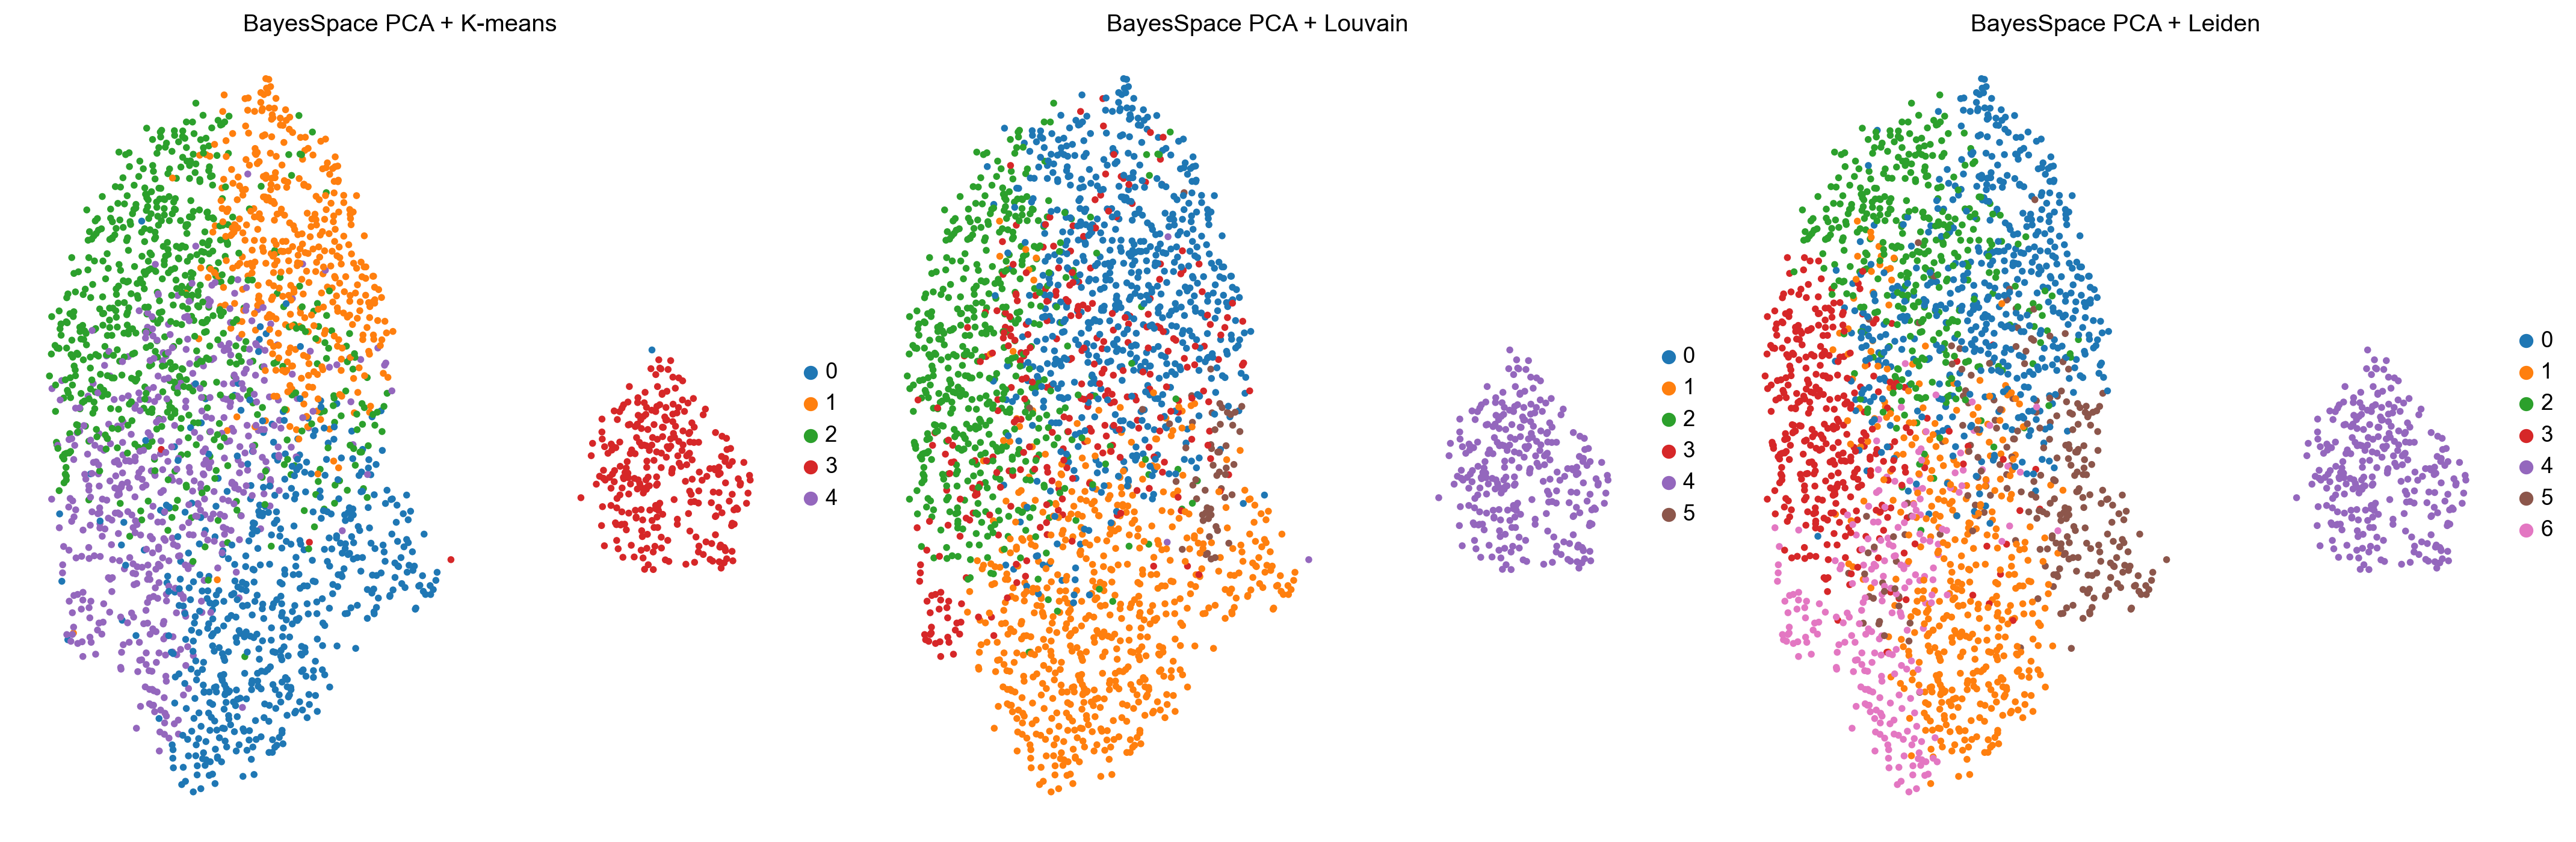

In [15]:
# -------------------------------
# 5. Plot: K-means / Louvain / Leiden
# -------------------------------

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sc.pl.umap(
    adata,
    color="bayes_kmeans",
    title="BayesSpace PCA + K-means",
    ax=axs[0],
    show=False
)

sc.pl.umap(
    adata,
    color="bayes_louvain",
    title="BayesSpace PCA + Louvain",
    ax=axs[1],
    show=False
)

sc.pl.umap(
    adata,
    color="bayes_leiden",
    title="BayesSpace PCA + Leiden",
    ax=axs[2],
    show=False
)

plt.tight_layout()
plt.show()

To benchmark representations, we applied identical clustering algorithms (Leiden, Louvain, K-means) on the BayesSpace PCA embedding and compared cluster separation to totalVI and our model.

To enable fair benchmarking across methods, we evaluated BayesSpace using its low-dimensional representation learned in R (BayesSpace PCA), rather than its native spatial MRF clustering. The BayesSpace PCA embedding was imported into Python and used to construct a k-nearest-neighbor graph, on which standard clustering algorithms (Leiden, Louvain, and K-means) were applied using identical parameters as for totalVI and our model. This isolates the quality of the learned representation and ensures that all methods are compared under the same downstream clustering and visualization pipeline. BayesSpace’s native spatial clustering was analyzed separately as a spatial segmentation baseline and was not used for cross-method benchmarking

# Metrics

In [17]:
#  check
print(adata.uns["neighbors"]["params"]["use_rep"])
# should be: 'X_bayes_pca'




X_bayes_pca


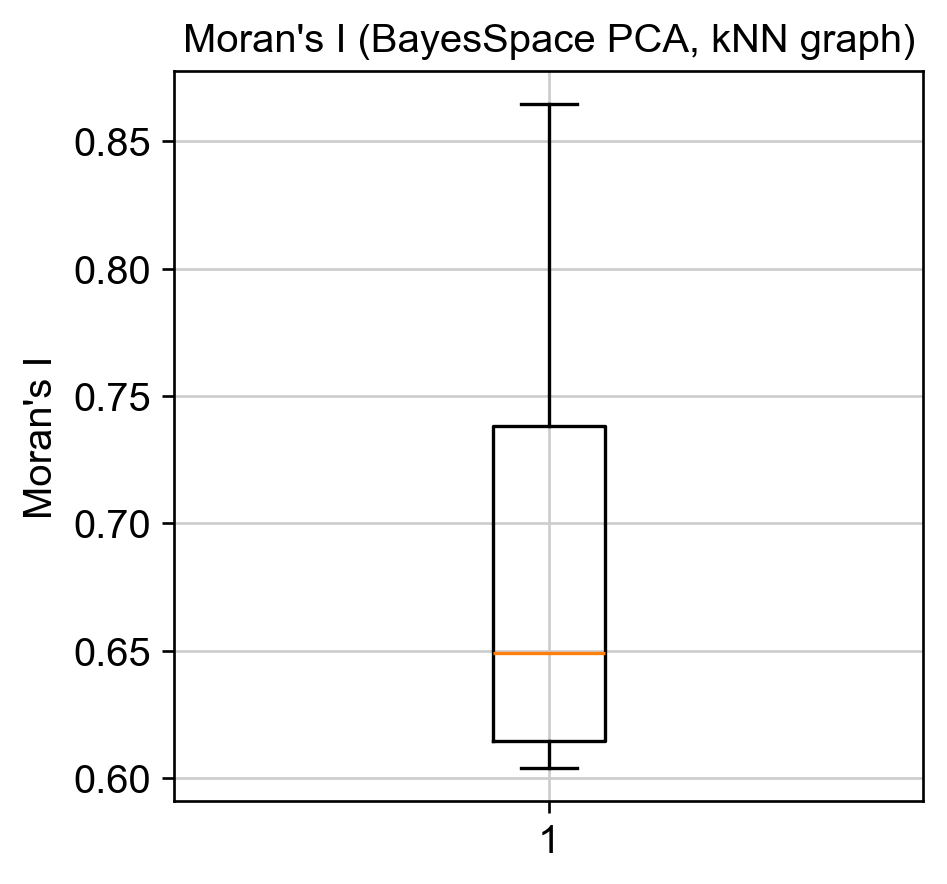

In [18]:
moran = sc.metrics.morans_i(
    adata,
    obsm="X_bayes_pca"
)

plt.boxplot(moran)
plt.ylabel("Moran's I")
plt.title("Moran's I (BayesSpace PCA, kNN graph)")
plt.show()

In [30]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# Used in Harmony, scIB, and original LISI paper
def compute_lisi(emb, labels, perplexity=30):
    n_neighbors = int(3 * perplexity)

    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)
    nn.fit(emb)
    _, indices = nn.kneighbors(emb)

    # drop self
    indices = indices[:, 1:]

    labels = np.asarray(labels)
    out = np.zeros(emb.shape[0])

    for i in range(emb.shape[0]):
        neigh = labels[indices[i]]
        p = pd.Series(neigh).value_counts(normalize=True)
        entropy = -(p * np.log(p)).sum()
        out[i] = np.exp(entropy)

    return out


In [31]:
X = adata.obsm["X_bayes_pca"]


In [32]:
labels_leiden  = adata.obs["bayes_leiden"]
labels_louvain = adata.obs["bayes_louvain"]
labels_kmeans  = adata.obs["bayes_kmeans"]


In [33]:
if "spatial.cluster" in adata.obs.columns:
    labels_bayes = adata.obs["spatial.cluster"]
else:
    labels_bayes = None


In [34]:
lisi_leiden  = compute_lisi(X, labels_leiden,  perplexity=30)
lisi_louvain = compute_lisi(X, labels_louvain, perplexity=30)
lisi_kmeans  = compute_lisi(X, labels_kmeans,  perplexity=30)

if labels_bayes is not None:
    lisi_bayes = compute_lisi(X, labels_bayes, perplexity=30)


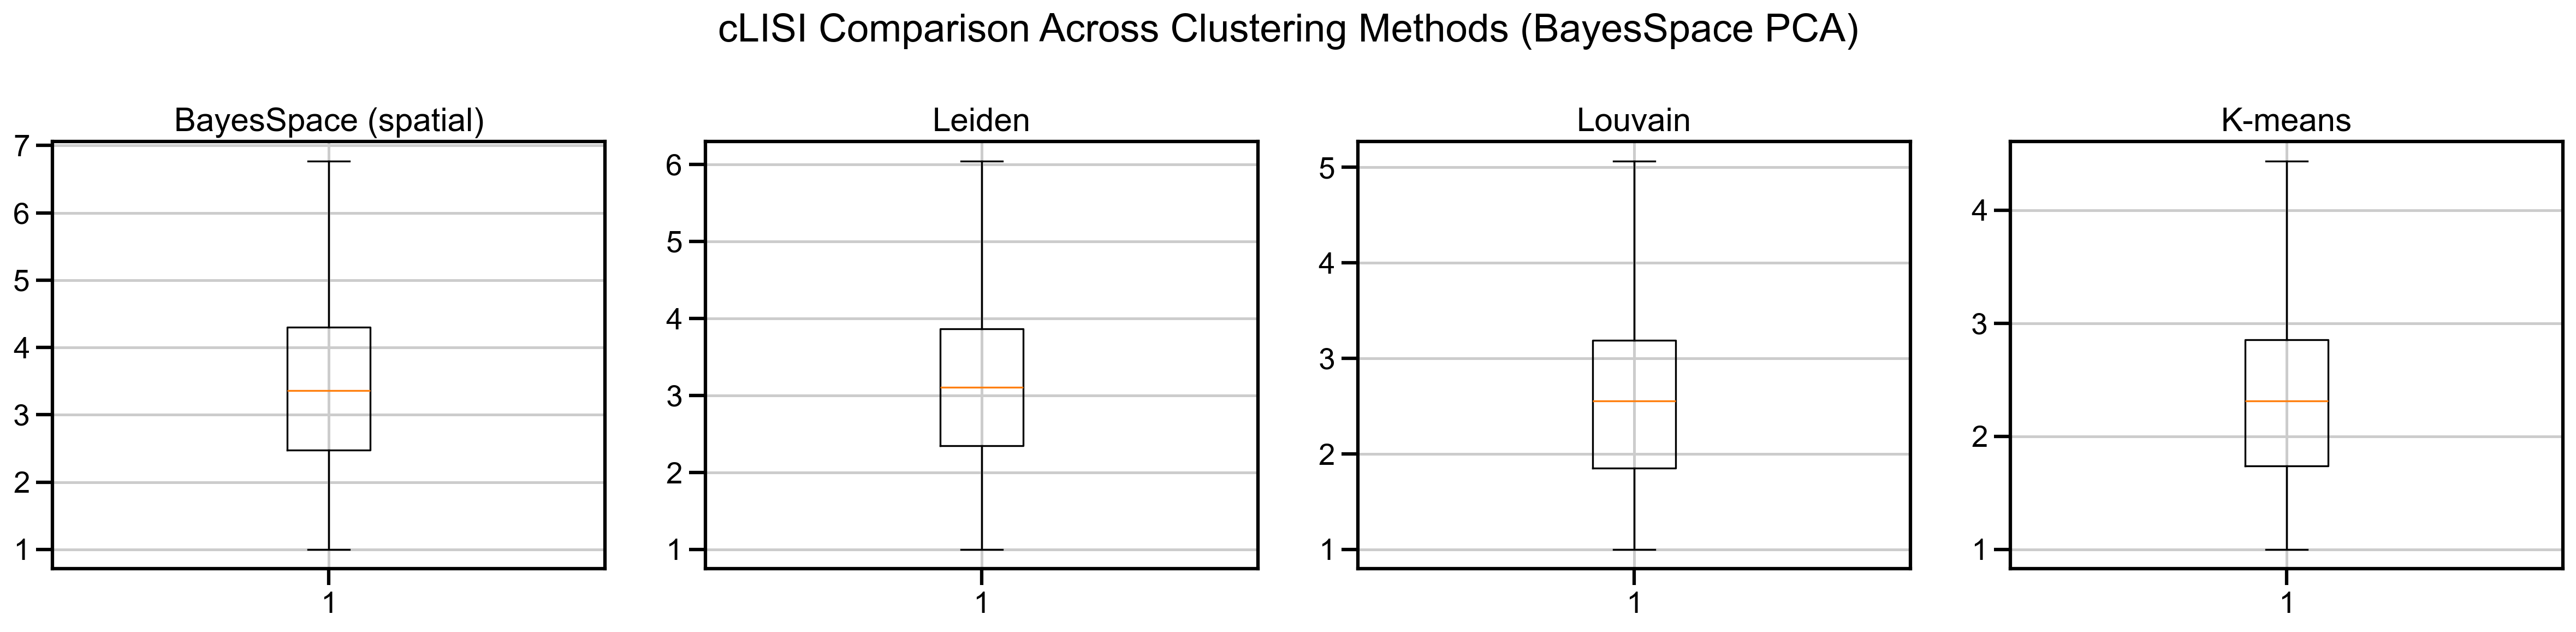

In [35]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

if labels_bayes is not None:
    axs[0].boxplot(lisi_bayes)
    axs[0].set_title("BayesSpace (spatial)")
else:
    axs[0].text(0.5, 0.5, "N/A", ha="center", va="center")
    axs[0].set_title("BayesSpace")

axs[1].boxplot(lisi_leiden)
axs[1].set_title("Leiden")

axs[2].boxplot(lisi_louvain)
axs[2].set_title("Louvain")

axs[3].boxplot(lisi_kmeans)
axs[3].set_title("K-means")

plt.suptitle("cLISI Comparison Across Clustering Methods (BayesSpace PCA)")
plt.tight_layout()
plt.show()


In [37]:
df_lisi = pd.DataFrame(
    {
        "LISI_kmeans":  lisi_kmeans,
        "LISI_louvain": lisi_louvain,
        "LISI_leiden":  lisi_leiden,
    },
    index=adata.obs_names
)


In [38]:
# mean
lisi_scores_mean = df_lisi.mean(axis=0)

# median
lisi_scores_median = df_lisi.median(axis=0)

print("Mean cLISI:")
print(lisi_scores_mean)

print("\nMedian cLISI:")
print(lisi_scores_median)


Mean cLISI:
LISI_kmeans     2.303012
LISI_louvain    2.537305
LISI_leiden     3.077861
dtype: float64

Median cLISI:
LISI_kmeans     2.313239
LISI_louvain    2.557090
LISI_leiden     3.103465
dtype: float64


In [39]:
lisi_scores_inv = 1 / lisi_scores_mean
# or, better:
# lisi_scores_inv = 1 / lisi_scores_median

lisi_scores_inv


LISI_kmeans     0.434214
LISI_louvain    0.394119
LISI_leiden     0.324901
dtype: float64

# Full DBI

In [43]:
# Full DBI
from sklearn.metrics import davies_bouldin_score
import numpy as np

X = adata.obsm["X_bayes_pca"]

dbi_leiden = davies_bouldin_score(
    X,
    adata.obs["bayes_leiden"].astype(int)
)

dbi_louvain = davies_bouldin_score(
    X,
    adata.obs["bayes_louvain"].astype(int)
)

dbi_kmeans = davies_bouldin_score(
    X,
    adata.obs["bayes_kmeans"].astype(int)
)

print("Davies–Bouldin Index (BayesSpace PCA)")
print("  Leiden: ", dbi_leiden)
print("  Louvain:", dbi_louvain)
print("  K-means:", dbi_kmeans)


Davies–Bouldin Index (BayesSpace PCA)
  Leiden:  2.5679040412089202
  Louvain: 2.4369916474377025
  K-means: 2.2859650833264284


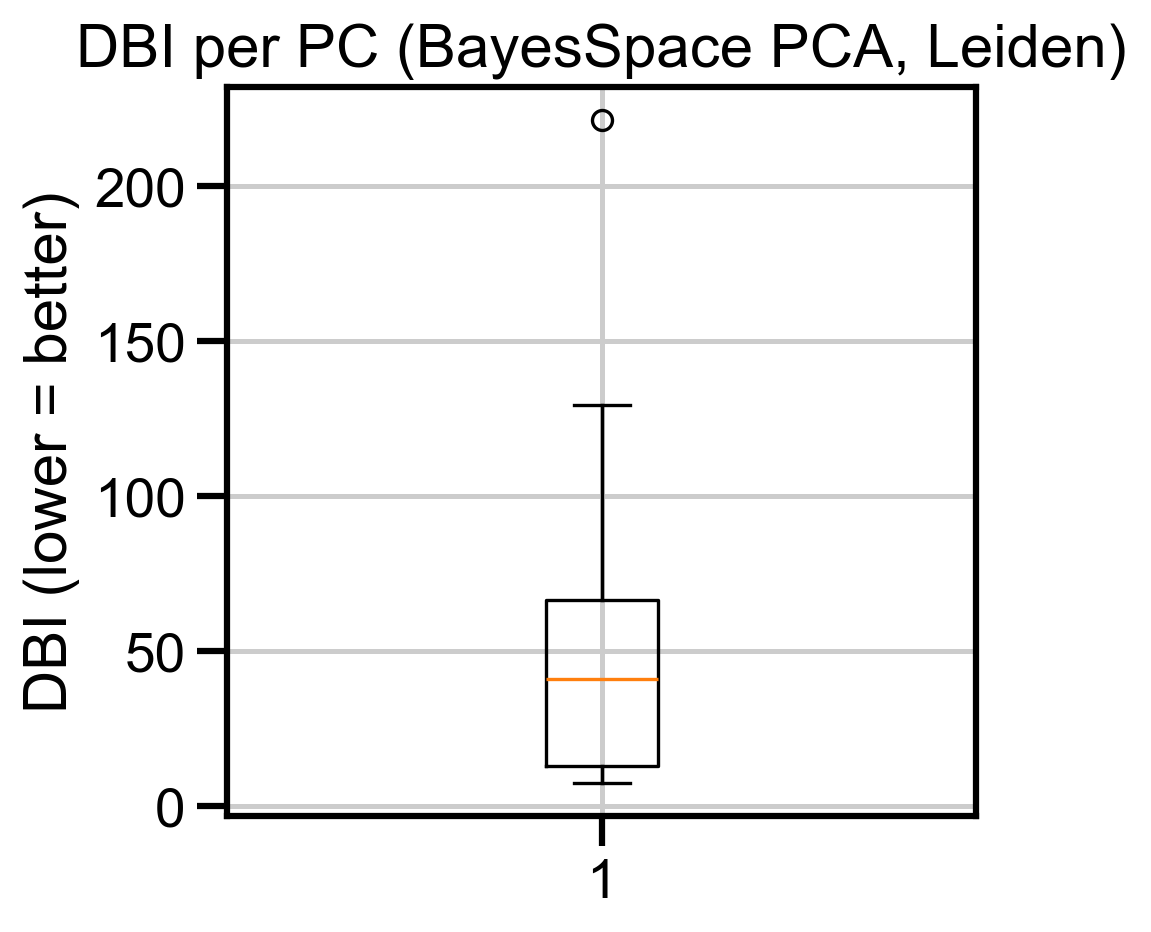

DBI per-PC statistics:
  Mean:   59.86245121239862
  Median: 41.10999925261574
  Std:    64.41466826962655


In [44]:
import matplotlib.pyplot as plt

labels = adata.obs["bayes_leiden"].astype(int).values

dbi_list = []
for i in range(X.shape[1]):
    Xi = X[:, i].reshape(-1, 1)
    dbi_list.append(davies_bouldin_score(Xi, labels))

dbi_list = np.array(dbi_list)

plt.boxplot(dbi_list)
plt.title("DBI per PC (BayesSpace PCA, Leiden)")
plt.ylabel("DBI (lower = better)")
plt.show()

print("DBI per-PC statistics:")
print("  Mean:  ", dbi_list.mean())
print("  Median:", np.median(dbi_list))
print("  Std:   ", dbi_list.std())


# Biological Accuracy

In [48]:
import mudata as md
import scanpy as sc

mdata = md.read_h5mu("/Users/mayjang/Desktop/536_project/data/tonsil_pp_svg_clean.h5mu")

rna_adata  = mdata.mod["RNA"]
prot_adata = mdata.mod["Protein"]


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [54]:
import pandas as pd

# Load BayesSpace clusters generated from bayespace.Rmd
clusters = pd.read_csv("data/bayes_space_data/bayespace_clusters.csv")

# Make sure the column is named cluster (or rename)
# clusters.columns = ["cell", "bayes_cluster"]
clusters["bayes_cluster"] = clusters["bayes_cluster"].astype(str)

pca = pd.read_csv("data/bayes_space_data/bayespace_pca.csv", index_col=0)
#make sure these match
print(rna_adata.obs_names[:5])
print(pca.index[:5])

rna_adata.obsm["X_bayes_pca"] = pca.values

# Assign BayesSpace cluster labels
rna_adata.obs["bayes_cluster"] = rna_adata.obs_names.map(
    dict(zip(clusters.cell, clusters.bayes_cluster))
)
rna_adata.obs["bayes_cluster"].isna().sum()


Index(['29x42', '44x36', '34x6', '42x19', '41x6'], dtype='object')
Index(['29x42', '44x36', '34x6', '42x19', '41x6'], dtype='object')


0

In [55]:
print(rna_adata)
print(rna_adata.obsm.keys())
print(rna_adata.obs.columns)


AnnData object with n_obs × n_vars = 2492 × 984
    obs: 'leiden', 'bayes_cluster'
    uns: 'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'pos', 'X_bayes_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
KeysView(AxisArrays with keys: X_pca, X_umap, pos, X_bayes_pca)
Index(['leiden', 'bayes_cluster'], dtype='object')


In [56]:
rna_adata.obs["cluster_eval"] = (
    rna_adata.obs["bayes_cluster"]  
    .astype(str)
    .astype("category")
)


In [57]:
sc.pp.normalize_total(rna_adata, target_sum=1e4)
sc.pp.log1p(rna_adata)


In [58]:
sc.tl.rank_genes_groups(
    rna_adata,
    groupby="cluster_eval",
    method="wilcoxon",
    key_added="bayes_wilcoxon"
)


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [59]:
rna_adata.uns["bayes_wilcoxon"].keys()


dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])

In [61]:
de_df = sc.get.rank_genes_groups_df(
    rna_adata,
    group=None,
    key="bayes_wilcoxon"
)

top = (
    de_df
    .query("pvals_adj < 0.05")
    .groupby("group")
    .head(30)
)

marker_genes = top["names"].unique().tolist()


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_61225/894697042.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")


In [62]:
rna_subset = rna_adata[:, marker_genes].copy()


In [63]:
sc.tl.dendrogram(
    rna_subset,
    groupby="cluster_eval",
    use_rep=None,   # disables PCA
    n_pcs=None
)


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See th

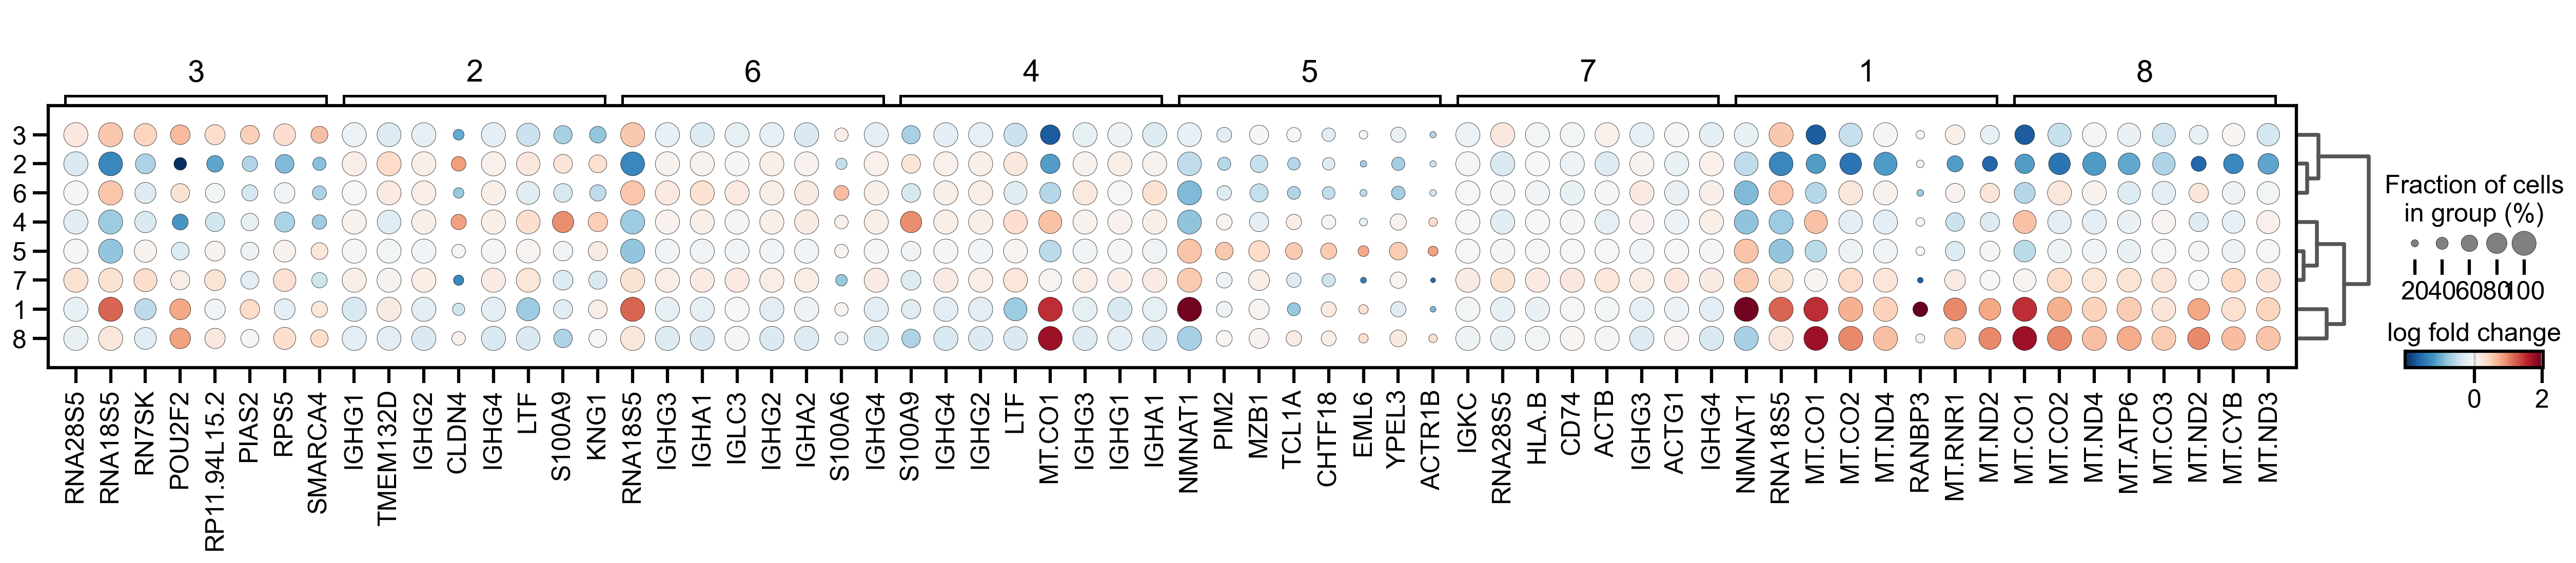

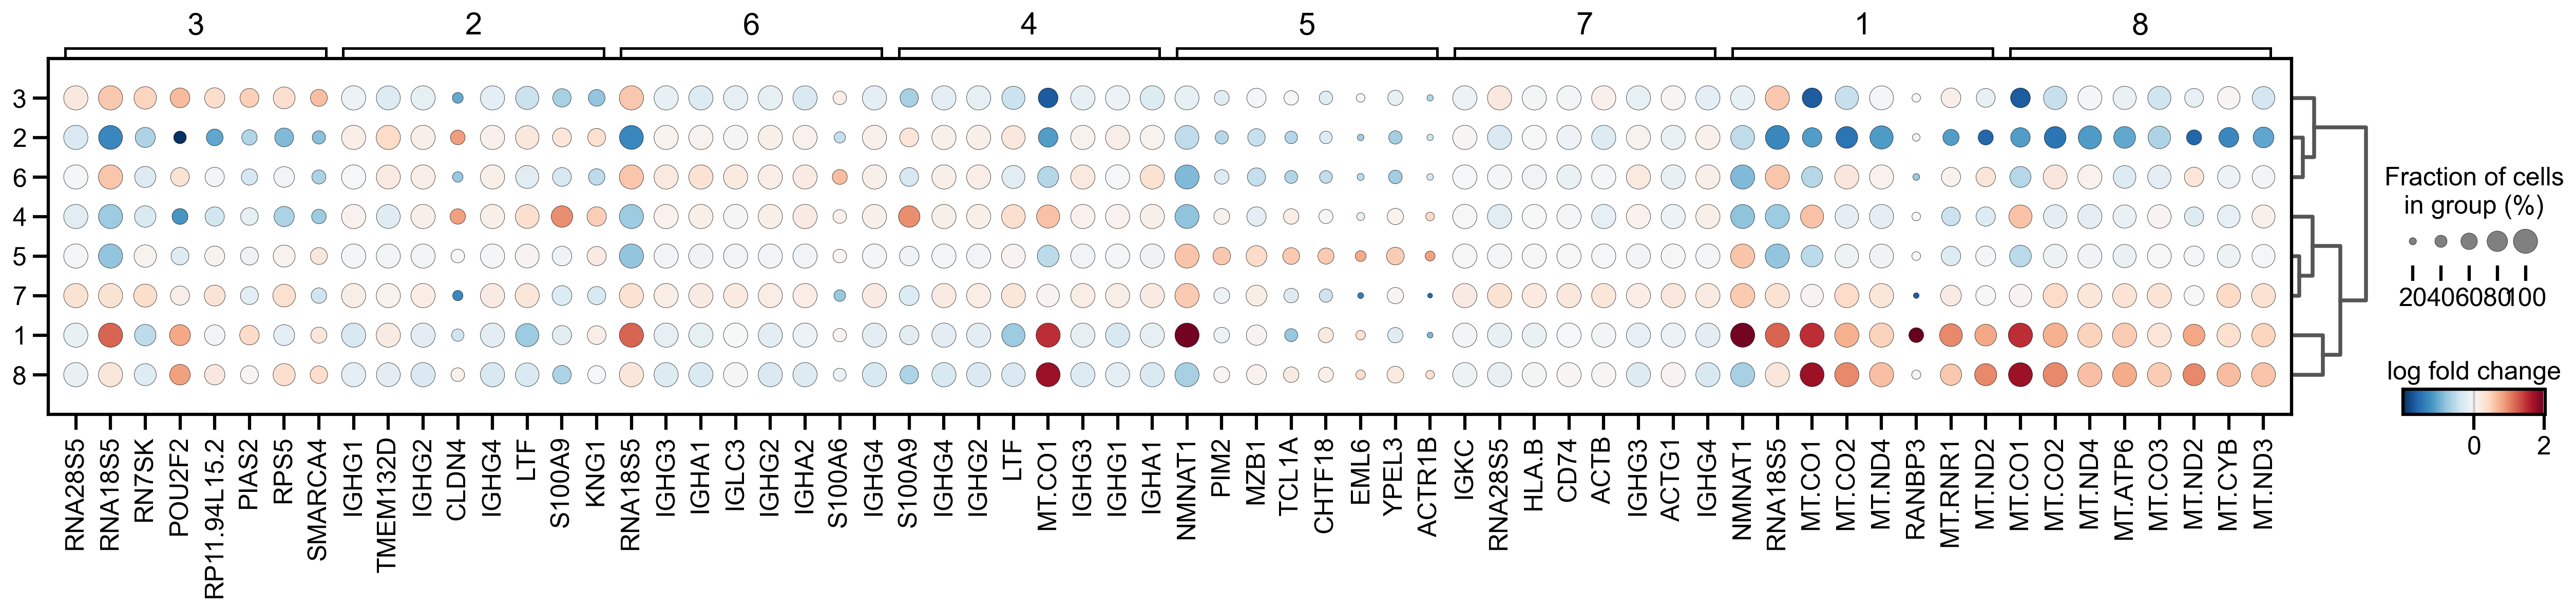

In [64]:
dot = sc.pl.rank_genes_groups_dotplot(
    rna_adata,
    groupby="cluster_eval",
    key="bayes_wilcoxon",
    n_genes=8,
    values_to_plot="logfoldchanges",
    cmap="RdBu_r",
    vcenter=0,
    dendrogram=True,
    return_fig=True,
    show=False
)

dot.savefig(
    "results/BayesSpace_RNA_DE_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)

dot.show()


In [68]:
rna_adata.uns.keys()


dict_keys(['leiden', 'leiden_colors', 'neighbors', 'pca', 'umap', 'log1p', 'bayes_wilcoxon', 'dendrogram_cluster_eval'])

# For Enrichment analysis in R

In [70]:
import gseapy as gp
import pandas as pd

# make sure cluster labels are strings
rna_adata.obs["cluster_eval"] = rna_adata.obs["cluster_eval"].astype(str)

# DE dataframe (already computed earlier)
de_df = sc.get.rank_genes_groups_df(
    rna_adata,
    group=None,
    key="bayes_wilcoxon"
)

writer = pd.ExcelWriter("results/bayes_space_results/bayesspace_enrichr.xlsx")

for clust in sorted(rna_adata.obs["cluster_eval"].unique()):
    # select significant DEGs for this cluster
    genes = (
        de_df
        .query("group == @clust and pvals_adj < 0.05")
        .sort_values("logfoldchanges", ascending=False)
        .head(100)["names"]
        .tolist()
    )

    if len(genes) == 0:
        continue

    enr = gp.enrichr(
        gene_list=genes,
        gene_sets="Azimuth_Cell_Types_2021",
        organism="Human",
        outdir=None,
        no_plot=True
    )

    enr.results.to_excel(
        writer,
        sheet_name=f"cluster_{clust}_up",
        index=False
    )

writer.close()


/Users/mayjang/miniconda3/envs/scverse_legacy/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
